# Stage 1: Empty vs. Animal Binary Classifier

**CPTS 434 — Automated Wildlife Classification**

This notebook implements Stage 1 of a two-stage wildlife classification pipeline on the Caltech Camera Traps (CCT20) dataset. The goal is a binary classifier: **empty** (no animal present) vs. **animal** (any species present).

**Design priority:** High recall on the animal class. A missed animal at Stage 1 is permanently lost and never reaches Stage 2 (species classification).

**Architecture:** ResNet-50 pretrained on ImageNet, with frozen backbone and a single linear classification head.

## 1. Setup & Imports

In [1]:
# Standard library
import os
import io
import json
import random
import copy
import time
from pathlib import Path
from collections import Counter, defaultdict

# Scientific computing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# torchvision
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights

# scikit-learn metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
)

# Image loading
from PIL import Image

# Progress bars
from tqdm.notebook import tqdm

# Version check
print(f"PyTorch version     : {torch.__version__}")
print(f"torchvision version : {torchvision.__version__}")

PyTorch version     : 2.10.0+cu128
torchvision version : 0.25.0+cu128


In [2]:
def set_seed(seed: int = 42):
    """Seed everything for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set to {seed}")

set_seed(42)

Seed set to 42


## 1b. Colab & GCS Setup

Run this cell in Google Colab to:
- Mount Google Drive (for persistent checkpoints / annotations)
- Install `gcsfs` for streaming images from the public LILA bucket
- Auto-sync annotation files from GCS → Drive (or print manual-upload instructions)

**Annotation files synced from GCS:**
- `caltech_bboxes_20200316.json` — unified COCO-style annotation file (~35 MB)
- `CaltechCameraTrapsSplits_v0.json` — LILA location-based train/val split file (~4 KB)

Skip this cell when running locally — `IS_COLAB` will be `False` and nothing executes.

In [3]:

# ── Colab detection ────────────────────────────────────────────────────────
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    # ── Mount Google Drive ──────────────────────────────────────────────────
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)

    # ── Install gcsfs for GCS image streaming ──────────────────────────────
    import subprocess
    subprocess.run(["pip", "install", "-q", "gcsfs"], check=True)

    import gcsfs

    DRIVE_ROOT = Path("/content/drive/MyDrive/CPTS434_wildlife")
    (DRIVE_ROOT / "annotations").mkdir(parents=True, exist_ok=True)
    (DRIVE_ROOT / "checkpoints").mkdir(parents=True, exist_ok=True)
    (DRIVE_ROOT / "results").mkdir(parents=True, exist_ok=True)

    # ── Annotation files to sync from GCS → Drive ─────────────────────────
    GCS_FILES = {
        "caltech_bboxes_20200316.json": (
            "public-datasets-lila/caltechcameratraps/labels/caltech_bboxes_20200316.json",
            DRIVE_ROOT / "annotations" / "caltech_bboxes_20200316.json",
        ),
        "CaltechCameraTrapsSplits_v0.json": (
            "public-datasets-lila/caltechcameratraps/CaltechCameraTrapsSplits_v0.json",
            DRIVE_ROOT / "annotations" / "CaltechCameraTrapsSplits_v0.json",
        ),
    }

    fs = gcsfs.GCSFileSystem(token="anon")

    for fname, (gcs_path, drive_path) in GCS_FILES.items():
        if drive_path.exists():
            print(f"[SKIP]  {fname} already on Drive.")
        else:
            try:
                print(f"[COPY]  {fname} from GCS ...", end=" ", flush=True)
                fs.get(gcs_path, str(drive_path))
                print("done.")
            except Exception as e:
                print(f"FAILED ({e})")
                print(f"  Manual download URL:")
                print(f"    https://storage.googleapis.com/{gcs_path}")
                print(f"  Upload to: {drive_path}")

    print("\nDrive layout:")
    for p in sorted((DRIVE_ROOT / "annotations").iterdir()):
        print(f"  {p}")
else:
    IS_COLAB = False
    print("Running locally — skipping Colab/GCS setup.")

Mounted at /content/drive
[SKIP]  caltech_bboxes_20200316.json already on Drive.
[SKIP]  CaltechCameraTrapsSplits_v0.json already on Drive.

Drive layout:
  /content/drive/MyDrive/CPTS434_wildlife/annotations/CaltechCameraTrapsSplits_v0.json
  /content/drive/MyDrive/CPTS434_wildlife/annotations/caltech_bboxes_20200316.json


In [4]:
# ── Auto-detect best available device ──────────────────────────────────────
if torch.cuda.is_available():
    _device = "cuda"
elif torch.backends.mps.is_available():
    _device = "mps"
else:
    _device = "cpu"

CONFIG = {
    # ── Annotation paths — auto-switch between Google Drive (Colab) and local
    "annotations_json": (
        Path("/content/drive/MyDrive/CPTS434_wildlife/annotations/caltech_bboxes_20200316.json")
        if IS_COLAB else Path("./caltech_bboxes_20200316.json")
    ),
    "splits_json": (
        Path("/content/drive/MyDrive/CPTS434_wildlife/annotations/CaltechCameraTrapsSplits_v0.json")
        if IS_COLAB else Path("./CaltechCameraTrapsSplits_v0.json")
    ),
    # image_dir is unused in GCS mode; set to local CCT image root otherwise
    "image_dir": None if IS_COLAB else Path("/path/to/cct_images"),
    "checkpoint_dir": (
        Path("/content/drive/MyDrive/CPTS434_wildlife/checkpoints")
        if IS_COLAB else Path("./checkpoints")
    ),
    "results_dir": (
        Path("/content/drive/MyDrive/CPTS434_wildlife/results")
        if IS_COLAB else Path("./results")
    ),

    # ── Google Drive / GCS (Colab only) ────────────────────────────────────
    "use_gcs"         : IS_COLAB,
    "gcs_image_prefix": "public-datasets-lila/caltech-unzipped/cct_images",
    "drive_root"      : Path("/content/drive/MyDrive/CPTS434_wildlife") if IS_COLAB else None,

    # ── Reproducibility ────────────────────────────────────────────────────
    "seed": 42,

    # ── Model ──────────────────────────────────────────────────────────────
    "model_name"      : "resnet50",
    "pretrained"      : True,
    "freeze_backbone" : True,    # Freeze all layers except the new FC head
    "unfreeze_layer4" : False,   # Set True to fine-tune layer4 as well

    # ── Training hyperparameters ───────────────────────────────────────────
    "num_epochs"   : 30,
    "batch_size"   : 64,
    # Colab A100: 4 workers parallelises GCS prefetching and keeps GPU fed.
    # If you see DataLoader timeouts, try num_workers=2, then 0 as last resort.
    "num_workers"  : 4,
    "learning_rate": 1e-3,
    "weight_decay" : 1e-4,

    # ── LR scheduler (ReduceLROnPlateau maximising val F1) ─────────────────
    "lr_patience"         : 4,
    "lr_factor"           : 0.1,
    "early_stop_patience" : 8,

    # ── Image processing ───────────────────────────────────────────────────
    "image_size": 224,

    # ── Class imbalance / recall tuning ───────────────────────────────────
    # pos_weight = (n_neg / n_pos) * pos_weight_multiplier
    # Increase above 1.0 to penalise false negatives more (higher recall).
    "pos_weight_multiplier": 1.0,

    # ── Decision threshold (applied at inference) ─────────────────────────
    # Lower → higher recall, more false positives.  Sweep cell will guide you.
    "decision_threshold": 0.5,

    # ── Device ─────────────────────────────────────────────────────────────
    "device": _device,
}

# Apply seed and create output directories
set_seed(CONFIG["seed"])
CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["results_dir"].mkdir(parents=True, exist_ok=True)

print(f"Device        : {CONFIG['device']}")
print(f"GCS mode      : {CONFIG['use_gcs']}")
print(f"Checkpoint dir: {CONFIG['checkpoint_dir'].resolve()}")
print(f"Results dir   : {CONFIG['results_dir'].resolve()}")

Seed set to 42
Device        : cuda
GCS mode      : True
Checkpoint dir: /content/drive/MyDrive/CPTS434_wildlife/checkpoints
Results dir   : /content/drive/MyDrive/CPTS434_wildlife/results


## 3. Dataset Download Instructions

Two annotation files are required. The setup cell (1b) attempts to copy them automatically from GCS. If that fails, download manually and upload to `/content/drive/MyDrive/CPTS434_wildlife/annotations/`.

### Annotation files

| File | Size | Description |
|------|------|-------------|
| `caltech_bboxes_20200316.json` | ~35 MB | Unified COCO-style annotation file — all images, bounding boxes, and category labels |
| `CaltechCameraTrapsSplits_v0.json` | ~4 KB | LILA location-based train / val split file |

### Manual download URLs (if GCS copy fails)

```
https://storage.googleapis.com/public-datasets-lila/caltechcameratraps/labels/caltech_bboxes_20200316.json
https://storage.googleapis.com/public-datasets-lila/caltechcameratraps/CaltechCameraTrapsSplits_v0.json
```

Upload both files to:
```
/content/drive/MyDrive/CPTS434_wildlife/annotations/
```

---

### Option B — Local machine

Download both files from the URLs above and place them in the same directory as this notebook (or update `annotations_json` / `splits_json` in `CONFIG`).

Images (~62 GB) stream on-demand from GCS in Colab mode. For local runs, set `image_dir` in `CONFIG` to the root of your extracted CCT image archive.

In [5]:
# ── Auto-detect best available device ──────────────────────────────────────
if torch.cuda.is_available():
    _device = "cuda"
elif torch.backends.mps.is_available():
    _device = "mps"
else:
    _device = "cpu"

CONFIG = {
    # ── Paths ──────────────────────────────────────────────────────────────
    # Update these to point to your local CCT dataset after downloading.
    "annotations_json": Path("./caltech_bboxes_20200316.json"),
    "splits_json"     : Path("./CaltechCameraTrapsSplits_v0.json"),
    "image_dir"       : Path("/path/to/cct_images"),
    "checkpoint_dir"  : Path("./checkpoints"),
    "results_dir"     : Path("./results"),

    # ── Reproducibility ────────────────────────────────────────────────────
    "seed": 42,

    # ── Model ──────────────────────────────────────────────────────────────
    "model_name"      : "resnet50",
    "pretrained"      : True,
    "freeze_backbone" : True,    # Freeze all layers except the new FC head
    "unfreeze_layer4" : False,   # Set True to fine-tune layer4 as well

    # ── Training hyperparameters ───────────────────────────────────────────
    "num_epochs"   : 30,
    "batch_size"   : 64,
    "num_workers"  : 4,
    "learning_rate": 1e-3,
    "weight_decay" : 1e-4,

    # ── LR scheduler (ReduceLROnPlateau maximising val F1) ─────────────────
    "lr_patience"         : 4,
    "lr_factor"           : 0.1,
    "early_stop_patience" : 8,

    # ── Image processing ───────────────────────────────────────────────────
    "image_size": 224,

    # ── Class imbalance / recall tuning ───────────────────────────────────
    # pos_weight = (n_neg / n_pos) * pos_weight_multiplier
    # Increase above 1.0 to penalise false negatives more (higher recall).
    "pos_weight_multiplier": 1.0,

    # ── Decision threshold (applied at inference) ─────────────────────────
    # Lower → higher recall, more false positives.  Sweep cell will guide you.
    "decision_threshold": 0.5,

    # ── Device ─────────────────────────────────────────────────────────────
    "device": _device,
}

# Apply seed and create output directories
set_seed(CONFIG["seed"])
CONFIG["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["results_dir"].mkdir(parents=True, exist_ok=True)

print(f"Device        : {CONFIG['device']}")
print(f"Checkpoint dir: {CONFIG['checkpoint_dir'].resolve()}")
print(f"Results dir   : {CONFIG['results_dir'].resolve()}")

Seed set to 42
Device        : cuda
Checkpoint dir: /content/checkpoints
Results dir   : /content/results


**`load_and_split_cct_annotations` — function signature**

```python
def load_and_split_cct_annotations(
    annotations_json,          # path to caltech_bboxes_20200316.json
    splits_json,               # path to CaltechCameraTrapsSplits_v0.json
    image_dir=None,            # local image root (ignored in GCS mode)
    use_gcs: bool = False,
    gcs_image_prefix: str = None,
    val_fraction: float = 0.75,
) -> tuple:                    # (train_samples, val_samples, test_samples)
```

Loads the unified CCT annotation file and the LILA split file, then partitions images into train / val / test by **camera location**. Test images are carved deterministically from the val locations:

```
sorted(unique val locations)[:round(N * val_fraction)]  →  val
sorted(unique val locations)[round(N * val_fraction):]  →  test
```

Each returned list contains `(img_path, label)` tuples where `label = 0` (empty) or `label = 1` (animal).

## 4. Data Loading & Label Creation

In [5]:
def load_and_split_cct_annotations(
    annotations_json,
    splits_json,
    image_dir=None,
    use_gcs: bool = False,
    gcs_image_prefix: str = None,
    val_fraction: float = 0.75,
) -> tuple:
    """
    Load the unified CCT annotation file and the LILA split file, then
    partition images into train / val / test by camera location.

    Test split is created deterministically from the val locations:
        sorted(unique val locations)[:round(N*val_fraction)] -> val
        sorted(unique val locations)[round(N*val_fraction):]  -> test

    Returns (train_samples, val_samples, test_samples)
        Each is a list of (img_path, label) where label 0=empty, 1=animal.
    """
    import json
    from collections import defaultdict
    from pathlib import Path

    # Load JSON files
    with open(annotations_json) as f:
        data = json.load(f)
    with open(splits_json) as f:
        splits_data = json.load(f)

    # Build location sets from split file (deduplicate, normalise to str)
    train_locs = set(str(x) for x in splits_data["splits"]["train"])
    val_locs_sorted = sorted(set(str(x) for x in splits_data["splits"]["val"]))
    n_val = round(len(val_locs_sorted) * val_fraction)
    val_locs  = set(val_locs_sorted[:n_val])
    test_locs = set(val_locs_sorted[n_val:])

    # Build empty category ID
    empty_cat_id = next(
        (cat["id"] for cat in data["categories"] if cat["name"].lower() == "empty"),
        None,
    )
    if empty_cat_id is None:
        raise ValueError(f"No 'empty' category found. Categories: "
                         f"{[c['name'] for c in data['categories']]}")

    # Build image_id -> annotations map
    image_id_to_anns = defaultdict(list)
    for ann in data["annotations"]:
        image_id_to_anns[ann["image_id"]].append(ann)

    # Assign images to splits
    train_samples, val_samples, test_samples = [], [], []
    skipped = 0

    for img in data["images"]:
        location = str(img["location"])

        if use_gcs:
            img_path = f"gs://{gcs_image_prefix}/{img['file_name']}"
        else:
            img_path = Path(image_dir) / img["file_name"]

        anns = image_id_to_anns[img["id"]]
        if len(anns) == 0 or all(a["category_id"] == empty_cat_id for a in anns):
            label = 0
        else:
            label = 1

        if location in train_locs:
            train_samples.append((img_path, label))
        elif location in val_locs:
            val_samples.append((img_path, label))
        elif location in test_locs:
            test_samples.append((img_path, label))
        else:
            skipped += 1

    if skipped:
        print(f"[INFO] {skipped} images had location IDs not in any split — skipped.")

    print(f"Split sizes — train: {len(train_samples)}, val: {len(val_samples)}, test: {len(test_samples)}")
    for name, samples in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
        if samples:
            empty = sum(1 for _, l in samples if l == 0)
            print(f"  {name}: {empty}/{len(samples)} empty ({100*empty/len(samples):.1f}%)")

    return train_samples, val_samples, test_samples


print("Loading annotations and applying location-based splits...")
train_samples, val_samples, test_samples = load_and_split_cct_annotations(
    CONFIG["annotations_json"],
    CONFIG["splits_json"],
    image_dir=CONFIG["image_dir"],
    use_gcs=CONFIG["use_gcs"],
    gcs_image_prefix=CONFIG["gcs_image_prefix"],
)

Loading annotations and applying location-based splits...
Split sizes — train: 37917, val: 23361, test: 1747
  train: 621/37917 empty (1.6%)
  val: 604/23361 empty (2.6%)
  test: 38/1747 empty (2.2%)


# ── Sample image grid: 4 empty + 4 animal ──────────────────────────────────
def show_sample_grid(samples, n_per_class=4, title="Sample Images"):
    empty_paths  = [p for p, l in samples if l == 0][:n_per_class]
    animal_paths = [p for p, l in samples if l == 1][:n_per_class]

    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    def _load_image(path):
        if CONFIG["use_gcs"]:
            fs = _get_gcs_fs()
            with fs.open(str(path), "rb") as f:
                return Image.open(io.BytesIO(f.read())).convert("RGB")
        else:
            return Image.open(path).convert("RGB")

    for col, path in enumerate(empty_paths):
        try:
            img = _load_image(path)
            axes[0, col].imshow(img)
        except Exception:
            axes[0, col].text(0.5, 0.5, "load error", ha="center", va="center")
        axes[0, col].axis("off")
        if col == 0:
            axes[0, col].set_ylabel("Empty", fontsize=11, rotation=90, labelpad=10)

    for col, path in enumerate(animal_paths):
        try:
            img = _load_image(path)
            axes[1, col].imshow(img)
        except Exception:
            axes[1, col].text(0.5, 0.5, "load error", ha="center", va="center")
        axes[1, col].axis("off")
        if col == 0:
            axes[1, col].set_ylabel("Animal", fontsize=11, rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()

show_sample_grid(train_samples, n_per_class=4, title="Training Set — Sample Images")

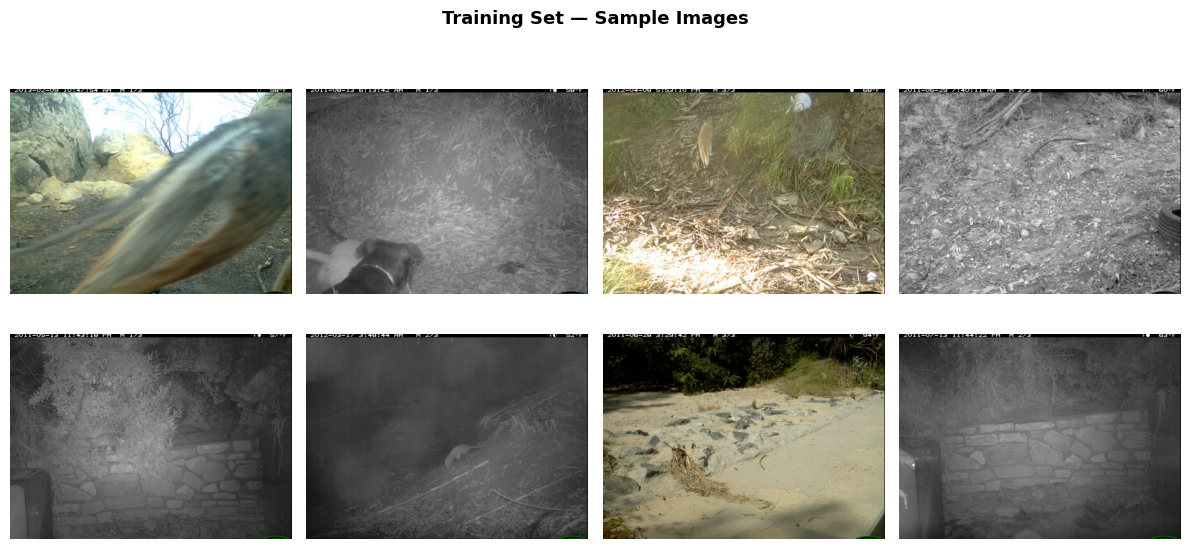

In [7]:
# Variables needed for this specific cell to run independently, derived from the show_sample_grid call in JvgJrWmdJf2D
n_per_class = 4
title = "Training Set — Sample Images"

# Assuming `train_samples` is available from the previous `load-cct20-code` cell.
# If not, you would need to define `train_samples` here or ensure `load-cct20-code` is run first.
empty_paths  = [p for p, l in train_samples if l == 0][:n_per_class]
animal_paths = [p for p, l in train_samples if l == 1][:n_per_class]

# Define _get_gcs_fs() locally for this cell, as it's used within _load_image
_gcs_fs_instance = None
def _get_gcs_fs():
    global _gcs_fs_instance
    if _gcs_fs_instance is None:
        import gcsfs
        _gcs_fs_instance = gcsfs.GCSFileSystem(token="anon")
    return _gcs_fs_instance

fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
fig.suptitle(title, fontsize=13, fontweight="bold")

def _load_image(path):
    if CONFIG["use_gcs"]:
        fs = _get_gcs_fs()
        with fs.open(str(path), "rb") as f:
            return Image.open(io.BytesIO(f.read())).convert("RGB")
    else:
        return Image.open(path).convert("RGB")

for col, path in enumerate(empty_paths):
    try:
        img = _load_image(path)
        axes[0, col].imshow(img)
    except Exception:
        axes[0, col].text(0.5, 0.5, "load error", ha="center", va="center")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Empty", fontsize=11, rotation=90, labelpad=10)

for col, path in enumerate(animal_paths):
    try:
        img = _load_image(path)
        axes[1, col].imshow(img)
    except Exception:
        axes[1, col].text(0.5, 0.5, "load error", ha="center", va="center")
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel("Animal", fontsize=11, rotation=90, labelpad=10)

plt.tight_layout()
plt.show()

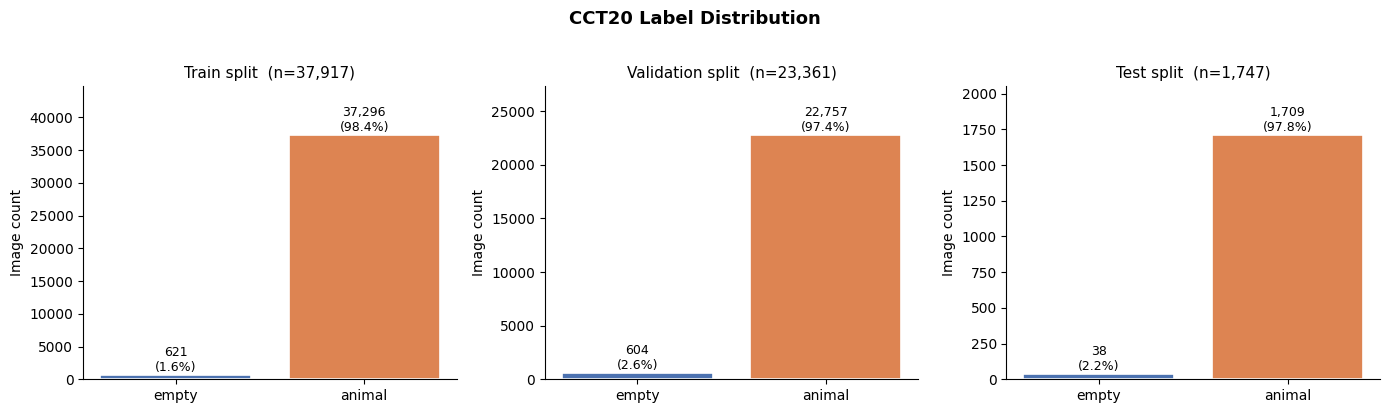

Saved class_distribution.png


In [8]:
# ── Class distribution bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names = ["empty", "animal"]
colors = ["#4C72B0", "#DD8452"]

for ax, (name, samples) in zip(
    axes,
    [("Train", train_samples), ("Validation", val_samples), ("Test", test_samples)]
):
    counts = Counter(label for _, label in samples)
    total  = len(samples)
    vals   = [counts[0], counts[1]]
    bars   = ax.bar(class_names, vals, color=colors, edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{v:,}\n({100*v/total:.1f}%)",
            ha="center", va="bottom", fontsize=9,
        )
    ax.set_title(f"{name} split  (n={total:,})", fontsize=11)
    ax.set_ylabel("Image count")
    ax.set_ylim(0, max(vals) * 1.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("CCT20 Label Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(CONFIG["results_dir"] / "class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved class_distribution.png")

In [ ]:
class CameraTrapsDataset(Dataset):
    """
    Binary dataset: empty (0) vs. animal (1).

    Parameters
    ----------
    samples   : list of (path, int) from load_and_split_cct_annotations().
                In GCS mode, path is a ``str``; in local mode, a ``Path``.
    transform : torchvision transform pipeline (different for train vs val/test)
    use_gcs   : if True, stream images from GCS via gcsfs instead of local disk
    """

    def __init__(self, samples: list, transform=None, use_gcs: bool = False):
        self.samples   = samples
        self.transform = transform
        self.use_gcs   = use_gcs

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, label = self.samples[idx]

        try:
            if self.use_gcs:
                # _get_gcs_fs() is called inside the worker process — safe with multiprocessing
                fs = _get_gcs_fs()
                # Strip "gs://" prefix: gcsfs.open() expects "bucket/path"
                gcs_key = str(img_path).removeprefix("gs://")
                with fs.open(gcs_key, "rb") as f:
                    image = Image.open(io.BytesIO(f.read())).convert("RGB")
            else:
                image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"[WARNING] Could not load {img_path}: {e}")
            size  = CONFIG.get("image_size", 224)
            image = Image.new("RGB", (size, size), (0, 0, 0))

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

    def get_labels(self) -> list:
        """Return flat list of integer labels — used to build WeightedRandomSampler."""
        return [label for _, label in self.samples]


print("CameraTrapsDataset class defined.")

## 6. PyTorch Dataset Class

In [ ]:
# ── ImageNet normalisation constants ───────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Training transforms (augmentation) ────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG["image_size"], scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Val / Test transforms (deterministic — NO augmentation) ───────────────
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CONFIG["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Build Datasets ─────────────────────────────────────────────────────────
train_dataset = CameraTrapsDataset(train_samples, transform=train_transform,
                                   use_gcs=CONFIG["use_gcs"])
val_dataset   = CameraTrapsDataset(val_samples,   transform=eval_transform,
                                   use_gcs=CONFIG["use_gcs"])
test_dataset  = CameraTrapsDataset(test_samples,  transform=eval_transform,
                                   use_gcs=CONFIG["use_gcs"])

# ── WeightedRandomSampler (balances class frequency in each batch) ─────────
train_labels   = train_dataset.get_labels()
label_counts   = Counter(train_labels)
n_total        = len(train_labels)

class_weights  = {cls: n_total / count for cls, count in label_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,
)

# ── DataLoaders ────────────────────────────────────────────────────────────
# GCS streaming notes (Colab A100):
#   - Cold reads add ~50–150 ms/image; num_workers=4 parallelises fetching
#     so the GPU stays fed during training.
#   - If you see DataLoader timeouts, try num_workers=2, then 0 as last resort.
#   - prefetch_factor=2 (default) is fine; don't increase above 4.
train_loader = DataLoader(
    train_dataset,
    batch_size  = CONFIG["batch_size"],
    sampler     = sampler,
    shuffle     = False,          # MUST be False with sampler
    num_workers = CONFIG["num_workers"],
    pin_memory  = (CONFIG["device"] == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = (CONFIG["device"] == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = (CONFIG["device"] == "cuda"),
)

print(f"Train batches : {len(train_loader):,}  ({len(train_dataset):,} images)")
print(f"Val   batches : {len(val_loader):,}  ({len(val_dataset):,} images)")
print(f"Test  batches : {len(test_loader):,}  ({len(test_dataset):,} images)")

## 7. Transforms & DataLoaders

In [ ]:
# ── ImageNet normalisation constants ───────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Training transforms (augmentation) ────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG["image_size"], scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Val / Test transforms (deterministic — NO augmentation) ───────────────
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(CONFIG["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Build Datasets ─────────────────────────────────────────────────────────
train_dataset = CameraTrapsDataset(train_samples, transform=train_transform)
val_dataset   = CameraTrapsDataset(val_samples,   transform=eval_transform)
test_dataset  = CameraTrapsDataset(test_samples,  transform=eval_transform)

# ── WeightedRandomSampler (balances class frequency in each batch) ─────────
train_labels   = train_dataset.get_labels()
label_counts   = Counter(train_labels)
n_total        = len(train_labels)

# Weight inversely proportional to class frequency
class_weights  = {cls: n_total / count for cls, count in label_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,
)

# ── DataLoaders ────────────────────────────────────────────────────────────
# NOTE: shuffle=False when using WeightedRandomSampler (they are mutually exclusive)
train_loader = DataLoader(
    train_dataset,
    batch_size  = CONFIG["batch_size"],
    sampler     = sampler,
    shuffle     = False,          # MUST be False with sampler
    num_workers = CONFIG["num_workers"],
    pin_memory  = (CONFIG["device"] == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = (CONFIG["device"] == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = (CONFIG["device"] == "cuda"),
)

print(f"Train batches : {len(train_loader):,}  ({len(train_dataset):,} images)")
print(f"Val   batches : {len(val_loader):,}  ({len(val_dataset):,} images)")
print(f"Test  batches : {len(test_loader):,}  ({len(test_dataset):,} images)")

In [ ]:
# ── Verify batch shapes and sampler balance ────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch image shape : {images.shape}   (expected [B, 3, 224, 224])")
print(f"Batch label shape : {labels.shape}   (expected [B])")
print(f"Label dtype       : {labels.dtype}   (expected torch.float32 for BCEWithLogitsLoss)")
animal_fraction = labels.sum().item() / len(labels)
print(f"Animal fraction in first batch: {animal_fraction:.3f}  (sampler target ~0.50)")

## 8. Model Definition

In [ ]:
def build_model(config: dict) -> nn.Module:
    """
    Build a ResNet-50 binary classifier.

    Architecture
    ------------
    - Pretrained ResNet-50 backbone (ImageNet weights)
    - Backbone frozen by default (only FC head is trained)
    - Single linear output node → BCEWithLogitsLoss expects a raw logit

    Critical note
    -------------
    Read ``in_features`` BEFORE replacing model.fc, otherwise you'll read 1
    (the new output size) instead of 2048 (the backbone feature size).
    """
    # ── Load pretrained backbone ──────────────────────────────────────────
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    # ── Freeze all parameters ─────────────────────────────────────────────
    if config["freeze_backbone"]:
        for param in model.parameters():
            param.requires_grad = False

    # ── Optionally unfreeze layer4 for deeper fine-tuning ─────────────────
    if config["unfreeze_layer4"]:
        for param in model.layer4.parameters():
            param.requires_grad = True

    # ── Read in_features BEFORE replacing the head ────────────────────────
    in_features = model.fc.in_features   # 2048 for ResNet-50

    # ── Replace classification head (single logit for binary task) ────────
    model.fc = nn.Linear(in_features, 1)
    # model.fc parameters are trainable by default (requires_grad=True)

    # ── Move to device ────────────────────────────────────────────────────
    device = config["device"]
    model  = model.to(device)

    # ── Parameter count summary ───────────────────────────────────────────
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params    = total_params - trainable_params

    print(f"Model         : ResNet-50")
    print(f"Total params  : {total_params:,}")
    print(f"Trainable     : {trainable_params:,}   (FC head: {in_features} × 1 + 1 bias)")
    print(f"Frozen        : {frozen_params:,}")
    print(f"Device        : {device}")

    return model


model = build_model(CONFIG)

## 9. Training Utilities

In [ ]:
def build_optimizer_and_loss(model: nn.Module, config: dict, class_counts: Counter):
    """
    Build loss, optimiser, and LR scheduler.

    BCEWithLogitsLoss pos_weight
    ----------------------------
    pos_weight = (n_negative / n_positive) * pos_weight_multiplier

    Increasing pos_weight_multiplier above 1.0 penalises false negatives more,
    pushing the model toward higher recall on the animal class — the Stage 1
    design goal.

    Scheduler
    ---------
    ReduceLROnPlateau in 'max' mode watching val F1 (not loss).  Accuracy
    alone is misleading on imbalanced data — a model predicting all-empty
    can exceed 70 % accuracy while being completely useless.
    """
    device = config["device"]

    n_neg = class_counts[0]
    n_pos = class_counts[1]
    pos_weight_value = (n_neg / n_pos) * config["pos_weight_multiplier"]
    pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    # Only optimise parameters that require gradients
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr           = config["learning_rate"],
        weight_decay = config["weight_decay"],
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode     = "max",           # maximise val F1
        patience = config["lr_patience"],
        factor   = config["lr_factor"],
    )

    print(f"pos_weight        : {pos_weight_value:.4f}  (n_neg={n_neg:,} / n_pos={n_pos:,} × {config['pos_weight_multiplier']})")
    print(f"Learning rate     : {config['learning_rate']}")
    print(f"Weight decay      : {config['weight_decay']}")
    print(f"LR scheduler      : ReduceLROnPlateau(mode=max, patience={config['lr_patience']}, factor={config['lr_factor']})")

    return criterion, optimizer, scheduler


train_class_counts = Counter(train_dataset.get_labels())
criterion, optimizer, scheduler = build_optimizer_and_loss(model, CONFIG, train_class_counts)

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Use tqdm for a progress bar
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]", leave=False)

    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1)  # Remove extra dimension for BCEWithLogitsLoss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        # Convert logits to probabilities and then predictions
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float() # Assuming a default threshold of 0.5 for accuracy calculation

        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device, decision_threshold):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_probs = []
    all_labels = []

    pbar = tqdm(dataloader, desc="[Val]", leave=False)

    with torch.no_grad():
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs).squeeze(1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs >= decision_threshold).float()

            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples

    # Calculate F1 score using sklearn
    all_preds_binary = (np.array(all_probs) >= decision_threshold).astype(int)
    f1 = f1_score(all_labels, all_preds_binary)

    return epoch_loss, epoch_acc, f1, np.array(all_probs), np.array(all_labels)

print("Training and validation utility functions defined.")

## 10. Training Loop

**Why F1 for model selection, not accuracy:**  
On CCT20 the empty class is dominant (>70 % of frames). A model that always predicts "empty" achieves >70 % accuracy while having zero utility. F1 on the animal class is a much more informative signal for model selection and learning-rate scheduling.

In [ ]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc" : [], "val_acc" : [],
    "val_f1"    : [],
}

best_val_f1              = -1.0
best_model_state         = None
epochs_without_improvement = 0
best_epoch               = 0

checkpoint_path = CONFIG["checkpoint_dir"] / "best_model.pth"

print(f"Training for up to {CONFIG['num_epochs']} epochs on {CONFIG['device']}")
print(f"Early stopping patience : {CONFIG['early_stop_patience']} epochs")
print(f"Best checkpoint         : {checkpoint_path}")
print("-" * 80)

for epoch in range(1, CONFIG["num_epochs"] + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, CONFIG["device"], epoch
    )

    # ── Validate ───────────────────────────────────────────────────────────
    val_loss, val_acc, val_f1, val_probs, val_labels = validate(
        model, val_loader, criterion, CONFIG["device"], CONFIG["decision_threshold"]
    )

    elapsed = time.time() - t0

    # ── Record history ─────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    # ── LR scheduling on val F1 (not loss) ────────────────────────────────
    scheduler.step(val_f1)

    # ── Best model checkpoint (deepcopy avoids live reference bug) ─────────
    if val_f1 > best_val_f1:
        best_val_f1              = val_f1
        best_epoch               = epoch
        epochs_without_improvement = 0
        best_model_state         = copy.deepcopy(model.state_dict())  # deepcopy is critical
        torch.save(
            {
                "epoch"            : epoch,
                "model_state_dict" : best_model_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "val_f1"           : val_f1,
                "config"           : {k: str(v) for k, v in CONFIG.items()},
            },
            checkpoint_path,
        )
        marker = "  ← best"
    else:
        epochs_without_improvement += 1
        marker = ""

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:3d}/{CONFIG['num_epochs']} | "
        f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
        f"Acc: {train_acc:.4f}/{val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{elapsed:.1f}s{marker}"
    )

    # ── Early stopping ─────────────────────────────────────────────────────
    if epochs_without_improvement >= CONFIG["early_stop_patience"]:
        print(f"\nEarly stopping triggered after {epoch} epochs (no improvement for {epochs_without_improvement} epochs).")
        break

print(f"\nTraining complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}.")
print(f"Best model saved to: {checkpoint_path}")

## 11. Results Visualization

In [ ]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curves ────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_ran, history["train_loss"], label="Train loss",  color="#4C72B0", linewidth=1.8)
ax.plot(epochs_ran, history["val_loss"],   label="Val loss",    color="#DD8452", linewidth=1.8)
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

# ── Accuracy + F1 curves ───────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_ran, history["train_acc"], label="Train acc",  color="#4C72B0", linewidth=1.8)
ax.plot(epochs_ran, history["val_acc"],   label="Val acc",    color="#DD8452", linewidth=1.8)
ax.plot(epochs_ran, history["val_f1"],    label="Val F1",     color="#55A868", linewidth=1.8, linestyle="-.")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1.2, label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Accuracy & Val F1")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Stage 1 Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()

curves_path = CONFIG["results_dir"] / "training_curves.png"
plt.savefig(curves_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {curves_path}")

## 12. Final Evaluation on Test Set

In [ ]:
# ── Load best checkpoint ───────────────────────────────────────────────────
# map_location ensures portability: checkpoint saved on GPU can be loaded on CPU
checkpoint = torch.load(checkpoint_path, map_location=CONFIG["device"])
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} (val F1 = {checkpoint['val_f1']:.4f})")

In [ ]:
# ── Run evaluation on test set ─────────────────────────────────────────────
test_loss, test_acc, test_f1, test_probs, test_labels = validate(
    model, test_loader, criterion, CONFIG["device"], CONFIG["decision_threshold"]
)

test_preds = (test_probs >= CONFIG["decision_threshold"]).astype(int)
test_labels_int = test_labels.astype(int)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print()
print(classification_report(
    test_labels_int, test_preds,
    target_names=["empty", "animal"],
    digits=4,
))

In [ ]:
# ── Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(test_labels_int, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted empty", "Predicted animal"],
    yticklabels=["Actual empty",    "Actual animal"],
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label",      fontsize=11)
ax.set_title("Confusion Matrix — Test Set", fontsize=12, fontweight="bold")

# Annotate with recall values
tn, fp, fn, tp = cm.ravel()
recall_empty  = tn / (tn + fp) if (tn + fp) > 0 else 0
recall_animal = tp / (tp + fn) if (tp + fn) > 0 else 0
ax.text(1.02, 0.85, f"Recall (empty) : {recall_empty:.3f}",  transform=ax.transAxes, fontsize=9)
ax.text(1.02, 0.75, f"Recall (animal): {recall_animal:.3f}", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
cm_path = CONFIG["results_dir"] / "confusion_matrix.png"
plt.savefig(cm_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {cm_path}")

In [ ]:
# ── ROC curve + AUC ────────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(test_labels_int, test_probs)
auc_score = roc_auc_score(test_labels_int, test_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"ROC curve (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random baseline")

# Mark operating point at chosen threshold
chosen_idx = np.argmin(np.abs(roc_thresholds - CONFIG["decision_threshold"]))
ax.scatter(
    fpr[chosen_idx], tpr[chosen_idx],
    color="red", s=80, zorder=5,
    label=f"Threshold = {CONFIG['decision_threshold']}",
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("ROC Curve — Test Set", fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
roc_path = CONFIG["results_dir"] / "roc_curve.png"
plt.savefig(roc_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"ROC-AUC = {auc_score:.4f}")
print(f"Saved {roc_path}")

In [ ]:
# ── Threshold sweep: precision, recall, F1 vs threshold ──────────────────
# This analysis justifies the chosen operating threshold and motivates
# Stage 2 design: prefer lower thresholds to maximise animal recall.

thresholds  = np.linspace(0.1, 0.9, 81)
precisions  = []
recalls     = []
f1_scores   = []

for t in thresholds:
    preds = (test_probs >= t).astype(int)
    tp = int(np.sum((preds == 1) & (test_labels_int == 1)))
    fp = int(np.sum((preds == 1) & (test_labels_int == 0)))
    fn = int(np.sum((preds == 0) & (test_labels_int == 1)))

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

best_f1_idx = int(np.argmax(f1_scores))
best_f1_threshold = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, label="Precision", color="#4C72B0", linewidth=1.8)
ax.plot(thresholds, recalls,    label="Recall",    color="#DD8452", linewidth=1.8)
ax.plot(thresholds, f1_scores,  label="F1",        color="#55A868", linewidth=1.8, linestyle="-.")
ax.axvline(CONFIG["decision_threshold"], color="red",  linestyle="--", linewidth=1.2,
           label=f"Config threshold ({CONFIG['decision_threshold']})")
ax.axvline(best_f1_threshold,            color="gray", linestyle=":",  linewidth=1.2,
           label=f"Best F1 threshold ({best_f1_threshold:.2f})")

ax.set_xlabel("Decision threshold", fontsize=11)
ax.set_ylabel("Score",              fontsize=11)
ax.set_title("Threshold Sweep — Animal Class", fontsize=12, fontweight="bold")
ax.legend(loc="lower left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
sweep_path = CONFIG["results_dir"] / "threshold_sweep.png"
plt.savefig(sweep_path, bbox_inches="tight", dpi=150)
plt.show()

print(f"Best F1 = {f1_scores[best_f1_idx]:.4f} at threshold = {best_f1_threshold:.2f}")
print(f"  Precision @ best F1 : {precisions[best_f1_idx]:.4f}")
print(f"  Recall    @ best F1 : {recalls[best_f1_idx]:.4f}")
print(f"Saved {sweep_path}")
print()
print("Stage 2 rationale: lower thresholds sacrifice precision to maximise recall.")
print("Missed animals at Stage 1 cannot be recovered by Stage 2.")

def predict_single_image(
    image_path,
    model: nn.Module,
    config: dict,
) -> tuple:
    """
    Run Stage 1 inference on a single image.

    Parameters
    ----------
    image_path : str or Path
        Local file path or ``gs://bucket/...`` GCS URI.
    model      : loaded nn.Module in eval mode
    config     : CONFIG dict (provides device, image_size, decision_threshold, use_gcs)

    Returns
    -------
    (prob_animal: float, label: str)
        prob_animal — probability of animal presence in [0, 1]
        label       — "animal" or "empty"
    """
    device    = config["device"]
    threshold = config["decision_threshold"]

    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(config["image_size"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    if config["use_gcs"] and str(image_path).startswith("gs://"):
        fs = _get_gcs_fs()
        gcs_key = str(image_path).removeprefix("gs://")
        with fs.open(gcs_key, "rb") as f:
            image = Image.open(io.BytesIO(f.read())).convert("RGB")
    else:
        image = Image.open(image_path).convert("RGB")

    tensor = transform(image).unsqueeze(0).to(device)   # [1, 3, H, W]

    model.eval()
    with torch.no_grad():
        logit = model(tensor)                            # [1, 1]
        prob  = torch.sigmoid(logit).item()

    label = "animal" if prob >= threshold else "empty"
    return prob, label


print("predict_single_image() defined.")

In [ ]:
# ── Example inference on a test image ─────────────────────────────────────
example_path, example_true_label = test_samples[0]
true_label_str = "animal" if example_true_label == 1 else "empty"

prob, predicted_label = predict_single_image(example_path, model, CONFIG)

fig, ax = plt.subplots(figsize=(5, 5))
try:
    if CONFIG["use_gcs"] and str(example_path).startswith("gs://"):
        fs = _get_gcs_fs()
        gcs_key = str(example_path).removeprefix("gs://")
        with fs.open(gcs_key, "rb") as f:
            display_img = Image.open(io.BytesIO(f.read())).convert("RGB")
    else:
        display_img = Image.open(example_path).convert("RGB")
    ax.imshow(display_img)
except Exception:
    ax.text(0.5, 0.5, "image load error", ha="center", va="center")

color = "green" if predicted_label == true_label_str else "red"
ax.set_title(
    f"True: {true_label_str}  |  Predicted: {predicted_label}  (p={prob:.3f})",
    color=color, fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()

# Display just the filename portion regardless of local/GCS path
img_name = str(example_path).split("/")[-1]
print(f"Image   : {img_name}")
print(f"P(animal) = {prob:.4f}")
print(f"Predicted : {predicted_label}  (threshold = {CONFIG['decision_threshold']})")
print(f"True label: {true_label_str}")

In [ ]:
def predict_single_image(
    image_path: str,
    model: nn.Module,
    config: dict,
) -> tuple:
    """
    Run Stage 1 inference on a single image.

    Parameters
    ----------
    image_path : str or Path — path to JPEG/PNG image
    model      : loaded nn.Module in eval mode
    config     : CONFIG dict (provides device, image_size, decision_threshold)

    Returns
    -------
    (prob_animal: float, label: str)
        prob_animal — probability of animal presence in [0, 1]
        label       — "animal" or "empty"
    """
    device    = config["device"]
    threshold = config["decision_threshold"]

    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(config["image_size"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)   # [1, 3, H, W]

    model.eval()
    with torch.no_grad():
        logit = model(tensor)                            # [1, 1]
        prob  = torch.sigmoid(logit).item()

    label = "animal" if prob >= threshold else "empty"
    return prob, label


print("predict_single_image() defined.")

In [ ]:
# ── Example inference on a test image ─────────────────────────────────────
# Pick the first test image for demonstration
example_path, example_true_label = test_samples[0]
true_label_str = "animal" if example_true_label == 1 else "empty"

prob, predicted_label = predict_single_image(example_path, model, CONFIG)

fig, ax = plt.subplots(figsize=(5, 5))
try:
    ax.imshow(Image.open(example_path).convert("RGB"))
except Exception:
    ax.text(0.5, 0.5, "image load error", ha="center", va="center")

color = "green" if predicted_label == true_label_str else "red"
ax.set_title(
    f"True: {true_label_str}  |  Predicted: {predicted_label}  (p={prob:.3f})",
    color=color, fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Image   : {example_path.name}")
print(f"P(animal) = {prob:.4f}")
print(f"Predicted : {predicted_label}  (threshold = {CONFIG['decision_threshold']})")
print(f"True label: {true_label_str}")

## Summary

| Artifact | Path |
|----------|------|
| Unified annotation file | `annotations/caltech_bboxes_20200316.json` |
| Location-based split file | `annotations/CaltechCameraTrapsSplits_v0.json` |
| Best checkpoint (used by Stage 2) | `checkpoints/best_model.pth` |
| Clean inference weights | `checkpoints/stage1_resnet50_final.pth` |
| TorchScript deployment model | `checkpoints/stage1_resnet50_traced.pt` |
| Training curves | `results/training_curves.png` |
| Confusion matrix | `results/confusion_matrix.png` |
| ROC curve | `results/roc_curve.png` |
| Threshold sweep | `results/threshold_sweep.png` |
| Class distribution | `results/class_distribution.png` |

### Key design decisions

- **High recall on animal class** is the primary Stage 1 objective. Adjust `pos_weight_multiplier` > 1.0 and/or lower `decision_threshold` to trade precision for recall.
- **Location-based splits** (from `CaltechCameraTrapsSplits_v0.json`) ensure that cameras in the test set were never seen during training — preventing spatial data leakage.
- **WeightedRandomSampler** ensures balanced mini-batches despite the class imbalance in CCT (~70 % empty frames).
- **F1-based model selection and LR scheduling** avoids the trap of optimising for accuracy on an imbalanced dataset.
- **Frozen backbone** with a single linear head trains quickly and generalises well; enable `unfreeze_layer4 = True` if you have GPU compute to spare.

### Next step: Stage 2 — Species Classification

Load `checkpoints/best_model.pth` from this notebook into `02_species_classifier.ipynb`. Only images that pass Stage 1 (predicted animal) are forwarded to Stage 2.